notebooks/02_rfm_segmentation.py
==================================
RFM segmentation analysis and visualisations.

NARRATIVE ARC OF THIS NOTEBOOK
-------------------------------
1. We compute raw RFM values per customer and score them into quintiles.
2. We apply a rule-based segmentation to produce named segments.
3. We visualise segment sizes and their revenue contribution.
4. For each segment we write a plain-English description + the business
   action it implies.

This notebook is the CORE BA deliverable of the project. The charts here
are what you would show in a stakeholder presentation. The business action
table (Section 4) is what drives the recommendations memo.

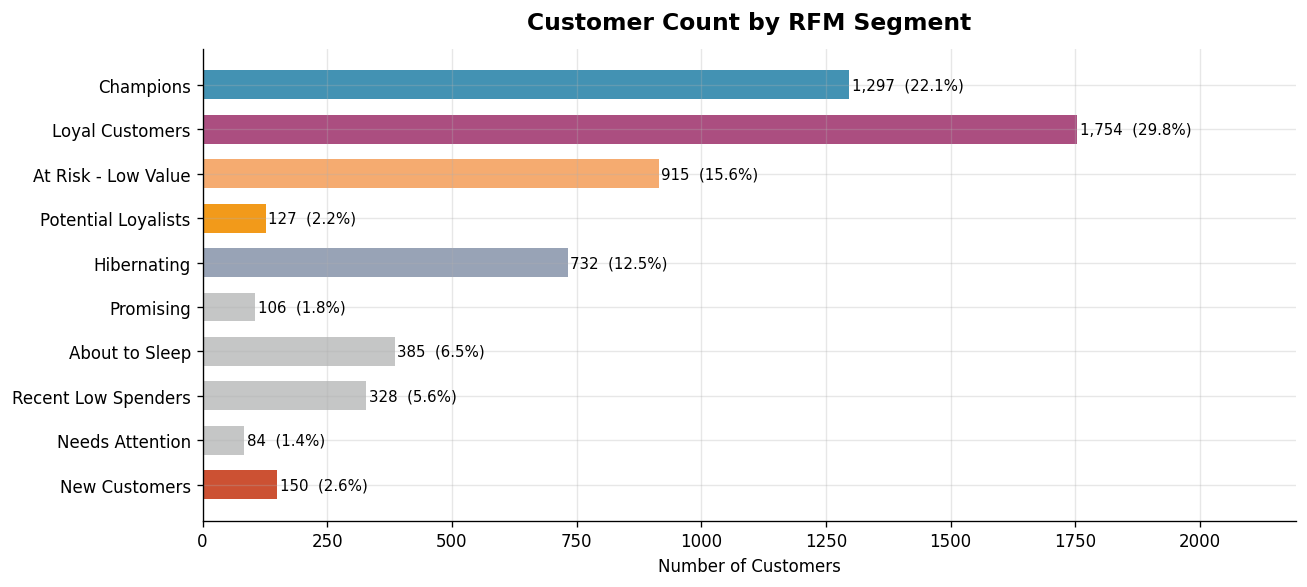

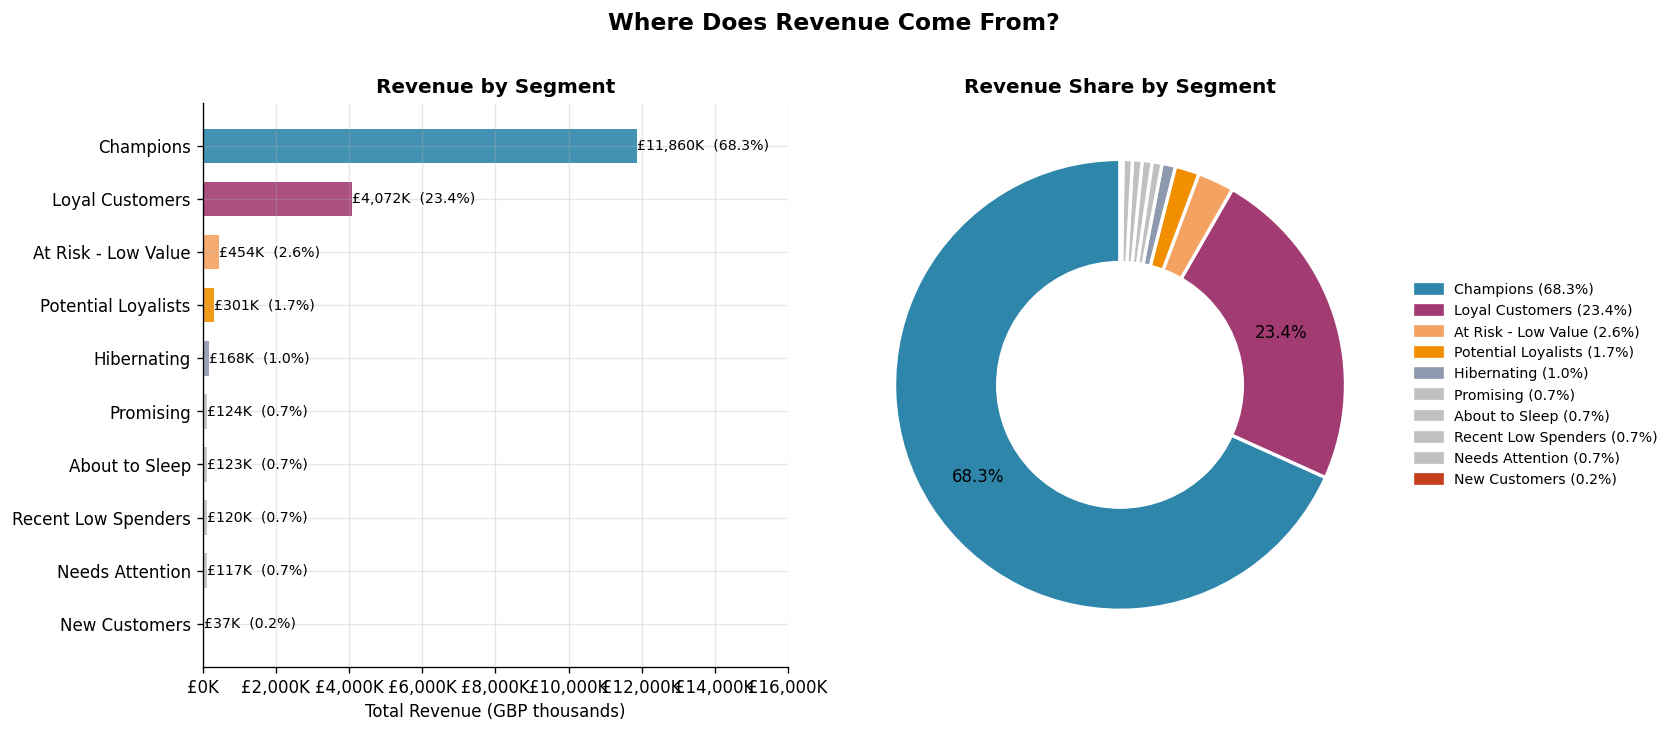

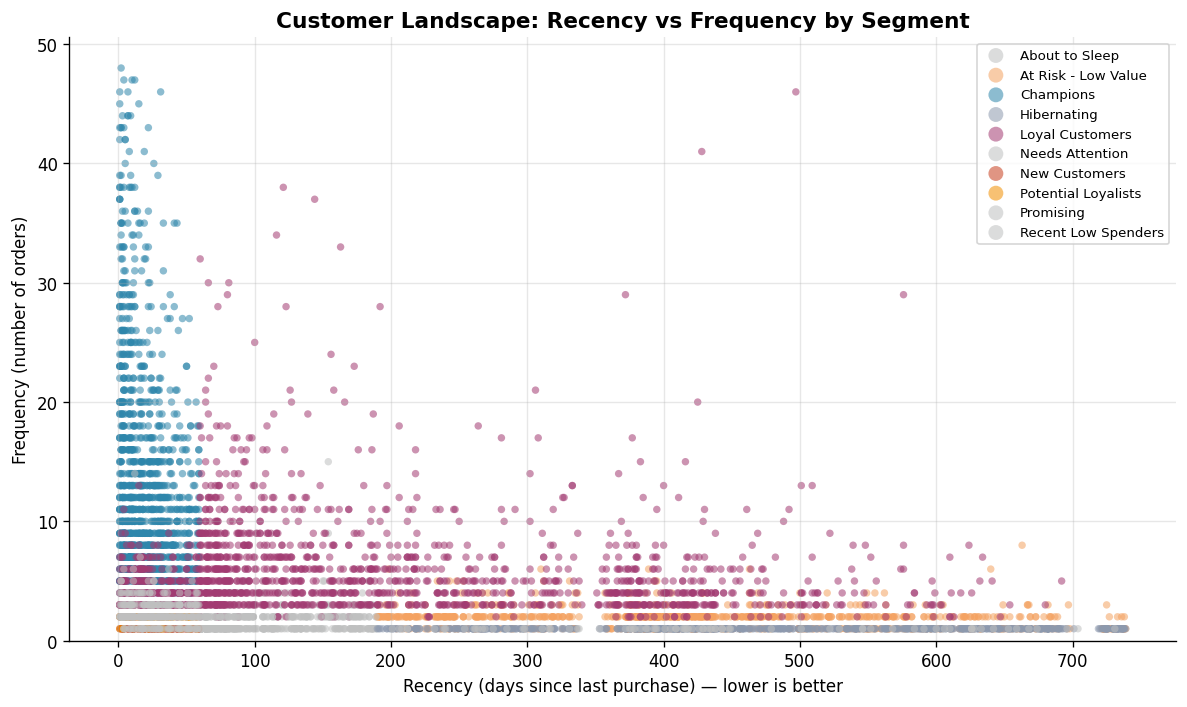

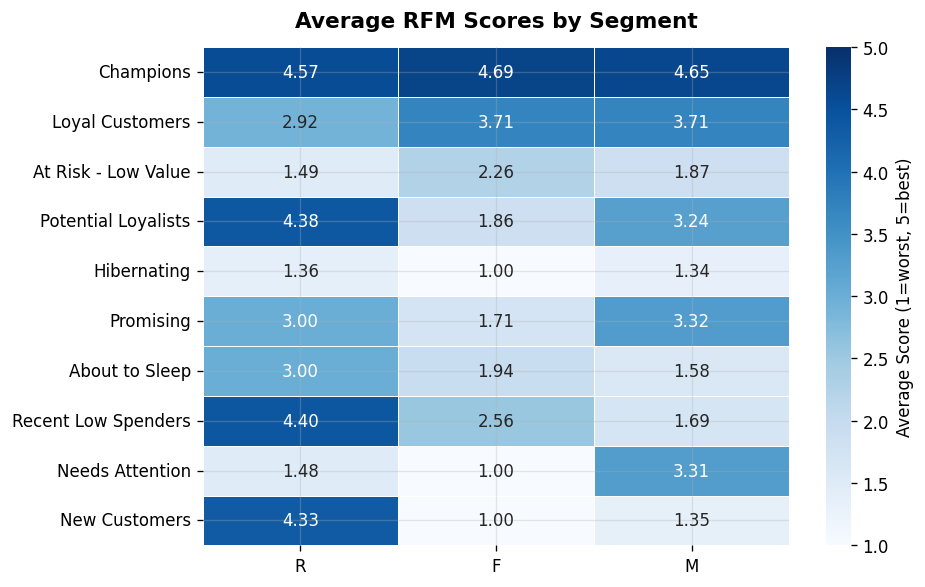

In [ ]:
import sys, os
from pathlib import Path
import matplotlib
matplotlib.use('Agg')

_NOTEBOOK_DIR = Path(__file__).resolve().parent
_PROJECT_ROOT = _NOTEBOOK_DIR.parent
sys.path.insert(0, str(_PROJECT_ROOT))
os.chdir(_PROJECT_ROOT)

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import matplotlib.patches as mpatches
import seaborn as sns

plt.rcParams.update({
    "figure.dpi": 120,
    "figure.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.3,
    "font.family": "sans-serif",
})

FIGURES_DIR = _PROJECT_ROOT / "data" / "processed" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

from src.data_cleaning import load_cleaned
from src.rfm import run_rfm_pipeline, SEGMENT_ACTIONS

# ── 1. Load and run pipeline ──────────────────────────────────────────────────
df = load_cleaned()
rfm = run_rfm_pipeline(df)

print(f"\nTotal customers segmented: {len(rfm):,}")
print(f"Unique segments: {rfm['Segment'].nunique()}")


# ── 2. Segment size and revenue contribution ──────────────────────────────────
# Build a clean summary table — this is the foundation of every chart

seg_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        TotalRevenue=("Monetary", "sum"),
        AvgRecency=("Recency", "mean"),
        AvgFrequency=("Frequency", "mean"),
        AvgMonetary=("Monetary", "mean"),
    )
    .reset_index()
)
seg_summary["CustomerPct"] = seg_summary["Customers"] / seg_summary["Customers"].sum() * 100
seg_summary["RevenuePct"] = seg_summary["TotalRevenue"] / seg_summary["TotalRevenue"].sum() * 100
seg_summary = seg_summary.sort_values("TotalRevenue", ascending=False).reset_index(drop=True)

# Colour palette — one consistent colour per segment throughout the notebook.
# Using a qualitative palette with enough contrast to read in B&W print.
SEGMENT_COLORS = {
    "Champions":           "#2E86AB",
    "Loyal Customers":     "#A23B72",
    "Potential Loyalists": "#F18F01",
    "New Customers":       "#C73E1D",
    "At Risk":             "#E84855",
    "At Risk - Low Value": "#F4A261",
    "Hibernating":         "#8D99AE",
    "Needs Attention":     "#BFC0C0",
}
seg_summary["Color"] = seg_summary["Segment"].map(SEGMENT_COLORS).fillna("#BFC0C0")

print("\nSegment summary:")
print(seg_summary[["Segment","Customers","CustomerPct","TotalRevenue","RevenuePct"]].to_string(index=False))


# ── Chart 1: Segment size (customer count) ────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 5))
bars = ax.barh(
    seg_summary["Segment"][::-1],
    seg_summary["Customers"][::-1],
    color=seg_summary["Color"][::-1].values,
    alpha=0.90,
    height=0.65,
)
for bar, (_, row) in zip(bars, seg_summary[::-1].iterrows()):
    ax.text(
        bar.get_width() + 5, bar.get_y() + bar.get_height() / 2,
        f"{row['Customers']:,}  ({row['CustomerPct']:.1f}%)",
        va="center", fontsize=9,
    )
ax.set_xlabel("Number of Customers")
ax.set_title("Customer Count by RFM Segment", fontsize=14, pad=12, fontweight="bold")
ax.set_xlim(0, seg_summary["Customers"].max() * 1.25)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "04_segment_sizes.png", bbox_inches="tight")
plt.close()
print("Saved: 04_segment_sizes.png")


# ── Chart 2: Revenue contribution per segment ─────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: bar chart (revenue amount)
bars = axes[0].barh(
    seg_summary["Segment"][::-1],
    seg_summary["TotalRevenue"][::-1] / 1000,
    color=seg_summary["Color"][::-1].values,
    alpha=0.90,
    height=0.65,
)
for bar, (_, row) in zip(bars, seg_summary[::-1].iterrows()):
    axes[0].text(
        bar.get_width() + 2, bar.get_y() + bar.get_height() / 2,
        f"£{row['TotalRevenue']/1000:,.0f}K  ({row['RevenuePct']:.1f}%)",
        va="center", fontsize=8.5,
    )
axes[0].set_xlabel("Total Revenue (GBP thousands)")
axes[0].set_title("Revenue by Segment", fontsize=12, fontweight="bold")
axes[0].set_xlim(0, seg_summary["TotalRevenue"].max() / 1000 * 1.35)
axes[0].xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"£{x:,.0f}K"))

# Right: donut chart (revenue share)
wedges, texts, autotexts = axes[1].pie(
    seg_summary["TotalRevenue"],
    labels=None,
    colors=seg_summary["Color"].values,
    autopct=lambda p: f"{p:.1f}%" if p > 3 else "",
    startangle=90,
    wedgeprops={"edgecolor": "white", "linewidth": 2},
    pctdistance=0.75,
)
# Add legend
legend_patches = [
    mpatches.Patch(color=row["Color"], label=f"{row['Segment']} ({row['RevenuePct']:.1f}%)")
    for _, row in seg_summary.iterrows()
]
axes[1].legend(handles=legend_patches, loc="center left", bbox_to_anchor=(1, 0.5),
               fontsize=8.5, frameon=False)
axes[1].set_title("Revenue Share by Segment", fontsize=12, fontweight="bold")

# Add centre circle (donut)
centre_circle = plt.Circle((0, 0), 0.55, fc="white")
axes[1].add_artist(centre_circle)

plt.suptitle("Where Does Revenue Come From?", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_segment_revenue.png", bbox_inches="tight")
plt.close()
print("Saved: 05_segment_revenue.png")


# ── Chart 3: Recency vs Frequency scatter, coloured by segment ───────────────
# WHY: This shows visually how segments occupy different behavioural spaces.
# Champions cluster top-left (low recency, high frequency).
# At-Risk cluster bottom-left or bottom-right.

fig, ax = plt.subplots(figsize=(10, 6))
for seg, group in rfm.groupby("Segment"):
    color = SEGMENT_COLORS.get(seg, "#BFC0C0")
    ax.scatter(
        group["Recency"],
        group["Frequency"],
        c=color,
        label=seg,
        alpha=0.55,
        s=20,
        edgecolors="none",
    )
ax.set_xlabel("Recency (days since last purchase) — lower is better")
ax.set_ylabel("Frequency (number of orders)")
ax.set_title("Customer Landscape: Recency vs Frequency by Segment", fontsize=13, fontweight="bold")
ax.legend(loc="upper right", fontsize=8, framealpha=0.8, markerscale=2)
# Cap y-axis at 99th percentile for readability
ax.set_ylim(0, rfm["Frequency"].quantile(0.99) * 1.1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_rfm_scatter.png", bbox_inches="tight")
plt.close()
print("Saved: 06_rfm_scatter.png")


# ── Chart 4: Average RFM scores per segment (heatmap) ────────────────────────
# This is the "fingerprint" chart — shows what makes each segment distinctive.

seg_scores = (
    rfm.groupby("Segment")[["R", "F", "M"]]
    .mean()
    .round(2)
    .reindex(seg_summary["Segment"])  # sort by revenue desc
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.heatmap(
    seg_scores,
    annot=True,
    fmt=".2f",
    cmap="Blues",
    linewidths=0.5,
    linecolor="white",
    ax=ax,
    vmin=1, vmax=5,
    cbar_kws={"label": "Average Score (1=worst, 5=best)"},
)
ax.set_title("Average RFM Scores by Segment", fontsize=13, fontweight="bold", pad=12)
ax.set_ylabel("")
ax.set_xlabel("")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "07_rfm_heatmap.png", bbox_inches="tight")
plt.close()
print("Saved: 07_rfm_heatmap.png")


# ── Section 4: Business action table ─────────────────────────────────────────
# This is the core BA output. For each segment:
#   - How many customers, how much revenue
#   - Plain-English description of who they are
#   - Specific recommended action

print("\n" + "="*70)
print("SEGMENT BUSINESS ACTIONS")
print("="*70)
for _, row in seg_summary.iterrows():
    seg = row["Segment"]
    print(f"\n[{seg}]")
    print(f"  Customers: {row['Customers']:,} ({row['CustomerPct']:.1f}% of base) | "
          f"Revenue: GBP {row['TotalRevenue']:,.0f} ({row['RevenuePct']:.1f}%)")
    print(f"  Avg Recency: {row['AvgRecency']:.0f} days | "
          f"Avg Orders: {row['AvgFrequency']:.1f} | "
          f"Avg Spend: GBP {row['AvgMonetary']:,.0f}")
    print(f"  ACTION: {SEGMENT_ACTIONS.get(seg, 'N/A')}")

print("\nRFM segmentation complete. All figures saved.")